# Behavioral Characterization of Large-Scale Network Traffic

### Exploratory Data Analysis (EDA)

Dataset:
- 3.57 Million Network Flows
- 82 Flow-Level Features
- 78 Application Protocol Categories

Objective:
Explore the statistical structure of network traffic and identify patterns that may reveal underlying behavioral characteristics independent of protocol labels.

# Dataset Overview

This notebook performs exploratory analysis on a large-scale network traffic dataset.

The goals of this stage are:

- Understand dataset composition
- Examine protocol distribution
- Investigate temporal characteristics
- Analyze flow duration and throughput distributions
- Detect skewness and outliers
- Identify feature relationships prior to dimensionality reduction

The findings from this notebook will guide preprocessing and feature engineering decisions in later stages.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
CSV_PATH = "Dataset-Unicauca-Version2-87Atts.csv"

sample = pd.read_csv(CSV_PATH)
sample.shape

(3577296, 87)

# Basic Dataset Statistics

The first step is to examine the overall structure of the dataset.

We inspect:

- Number of observations
- Number of features
- Data types
- Missing values
- Summary statistics

This provides an initial understanding of feature ranges and potential preprocessing requirements.

In [3]:
sample.head()

,Flow.ID,Source.IP,Source.Port,Destination.IP,Destination.Port,Protocol,Timestamp,Flow.Duration,Total.Fwd.Packets,Total.Backward.Packets,...,Active.Std,Active.Max,Active.Min,Idle.Mean,Idle.Std,Idle.Max,Idle.Min,Label,L7Protocol,ProtocolName
0,172.19.1.46-10.200.7.7-52422-3128-6,172.19.1.46,52422,10.200.7.7,3128,6,26/04/201711:11:17,45523,22,55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,131,HTTP_PROXY
1,172.19.1.46-10.200.7.7-52422-3128-6,10.200.7.7,3128,172.19.1.46,52422,6,26/04/201711:11:17,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,131,HTTP_PROXY
2,10.200.7.217-50.31.185.39-38848-80-6,50.31.185.39,80,10.200.7.217,38848,6,26/04/201711:11:17,1,3,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,7,HTTP
3,10.200.7.217-50.31.185.39-38848-80-6,50.31.185.39,80,10.200.7.217,38848,6,26/04/201711:11:17,217,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,7,HTTP
4,192.168.72.43-10.200.7.7-55961-3128-6,192.168.72.43,55961,10.200.7.7,3128,6,26/04/201711:11:17,78068,5,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,131,HTTP_PROXY


Reformatting Timestamp to regular format

In [4]:
sample['Timestamp'] = sample['Timestamp'].str.replace(r'(\d{4})(\d{2}:\d{2}:\d{2})',r'\1 \2',regex=True)

In [5]:
for i, col in enumerate(sample.columns):
    print(f" {col}")

 Flow.ID
 Source.IP
 Source.Port
 Destination.IP
 Destination.Port
 Protocol
 Timestamp
 Flow.Duration
 Total.Fwd.Packets
 Total.Backward.Packets
 Total.Length.of.Fwd.Packets
 Total.Length.of.Bwd.Packets
 Fwd.Packet.Length.Max
 Fwd.Packet.Length.Min
 Fwd.Packet.Length.Mean
 Fwd.Packet.Length.Std
 Bwd.Packet.Length.Max
 Bwd.Packet.Length.Min
 Bwd.Packet.Length.Mean
 Bwd.Packet.Length.Std
 Flow.Bytes.s
 Flow.Packets.s
 Flow.IAT.Mean
 Flow.IAT.Std
 Flow.IAT.Max
 Flow.IAT.Min
 Fwd.IAT.Total
 Fwd.IAT.Mean
 Fwd.IAT.Std
 Fwd.IAT.Max
 Fwd.IAT.Min
 Bwd.IAT.Total
 Bwd.IAT.Mean
 Bwd.IAT.Std
 Bwd.IAT.Max
 Bwd.IAT.Min
 Fwd.PSH.Flags
 Bwd.PSH.Flags
 Fwd.URG.Flags
 Bwd.URG.Flags
 Fwd.Header.Length
 Bwd.Header.Length
 Fwd.Packets.s
 Bwd.Packets.s
 Min.Packet.Length
 Max.Packet.Length
 Packet.Length.Mean
 Packet.Length.Std
 Packet.Length.Variance
 FIN.Flag.Count
 SYN.Flag.Count
 RST.Flag.Count
 PSH.Flag.Count
 ACK.Flag.Count
 URG.Flag.Count
 CWE.Flag.Count
 ECE.Flag.Count
 Down.Up.Ratio
 Average.Packet

# Application Protocol Distribution

Network traffic is generated by a diverse set of applications and services.

This section examines the distribution of protocol labels to understand:

- Dominant applications
- Class imbalance
- Long-tail protocol behavior

Although protocol labels will not be used directly for clustering, they provide useful context for interpreting discovered traffic patterns.

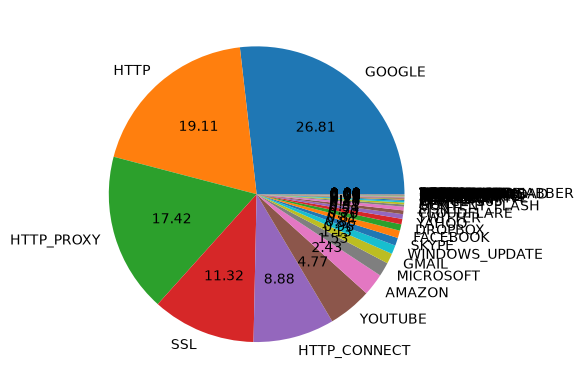

In [19]:
counts = sample['ProtocolName'].value_counts()

plt.pie(counts,labels=counts.index,autopct='%.2f')
plt.show()

# Flow Duration Analysis

Flow duration is one of the most informative network traffic features.

This section investigates:

- Duration distribution
- Presence of long-lived sessions
- Short burst traffic
- Potential heavy-tail behavior

Network traffic often exhibits strong skewness, making duration a key candidate for transformation during preprocessing.

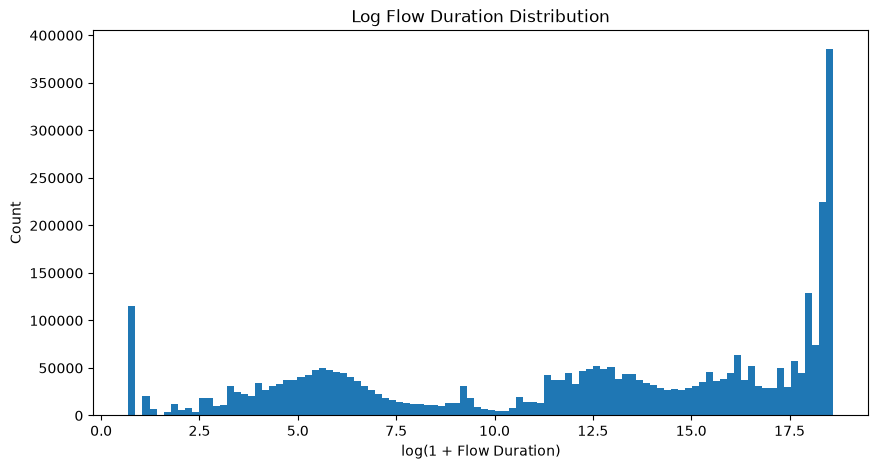

In [25]:
plt.figure(figsize=(10,5))
plt.hist(np.log1p(sample['Flow.Duration']), bins=100)
plt.title("Log Flow Duration Distribution")
plt.xlabel("log(1 + Flow Duration)")
plt.ylabel("Count")
plt.show()

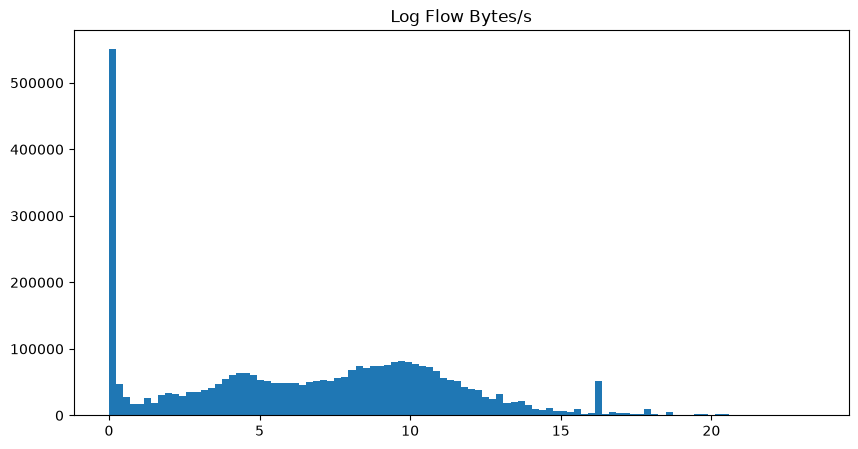

In [8]:
plt.figure(figsize=(10,5))
plt.hist(np.log1p(sample['Flow.Bytes.s']), bins=100)
plt.title("Log Flow Bytes/s")
plt.show()

# Distribution and Outlier Analysis

Network traffic features are known to exhibit extreme outliers and heavy-tailed distributions.

Boxplots are used to:

- Visualize feature spread
- Identify outliers
- Compare protocol-specific behavior

These observations motivate later normalization and logarithmic transformations.

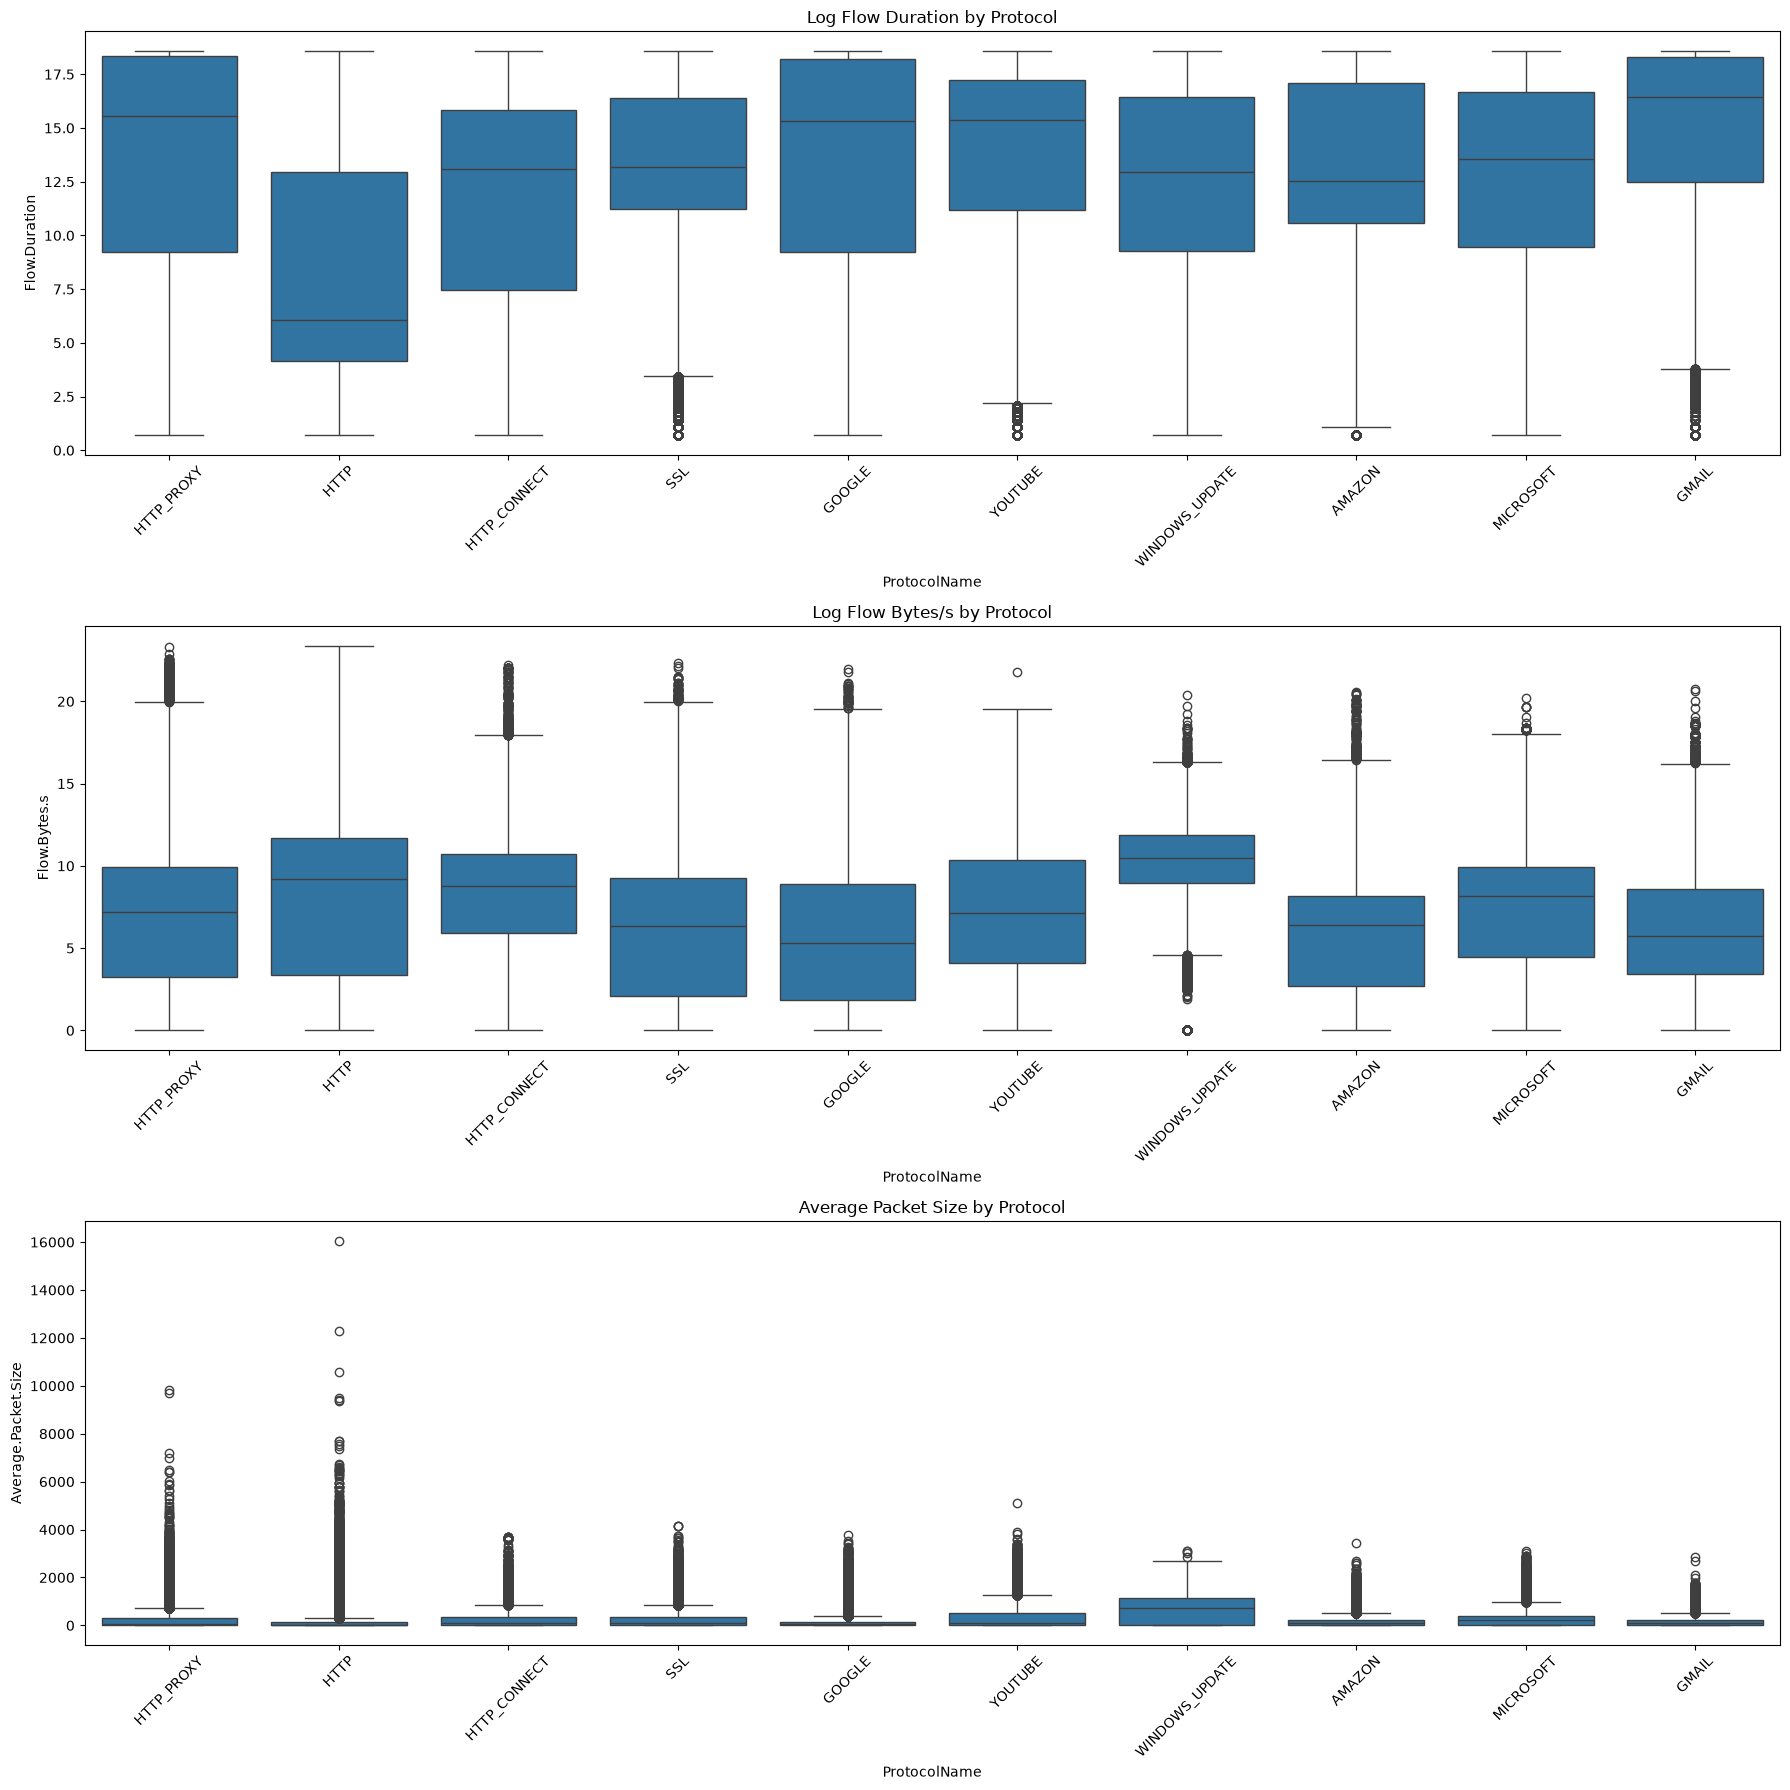

In [ ]:
top10 = sample['ProtocolName'].value_counts().head(10).index

tmp = sample[sample['ProtocolName'].isin(top10)].copy()

fig, axes = plt.subplots(3, 1, figsize=(18, 18))


sns.boxplot(data=tmp,x='ProtocolName',y=np.log1p(tmp['Flow.Duration']),ax=axes[0])
axes[0].set_title('Log Flow Duration by Protocol')
axes[0].tick_params(axis='x', rotation=45)


sns.boxplot(data=tmp,x='ProtocolName',y=np.log1p(tmp['Flow.Bytes.s']),ax=axes[1])
axes[1].set_title('Log Flow Bytes/s by Protocol')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=tmp,x='ProtocolName',y='Average.Packet.Size',ax=axes[2])
axes[2].set_title('Average Packet Size by Protocol')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Correlation Structure

Many network features are derived from common underlying quantities.

Correlation analysis helps identify:

- Redundant variables
- Strong feature dependencies
- Potential dimensionality reduction opportunities

Highly correlated features are expected due to packet-count and byte-count relationships.

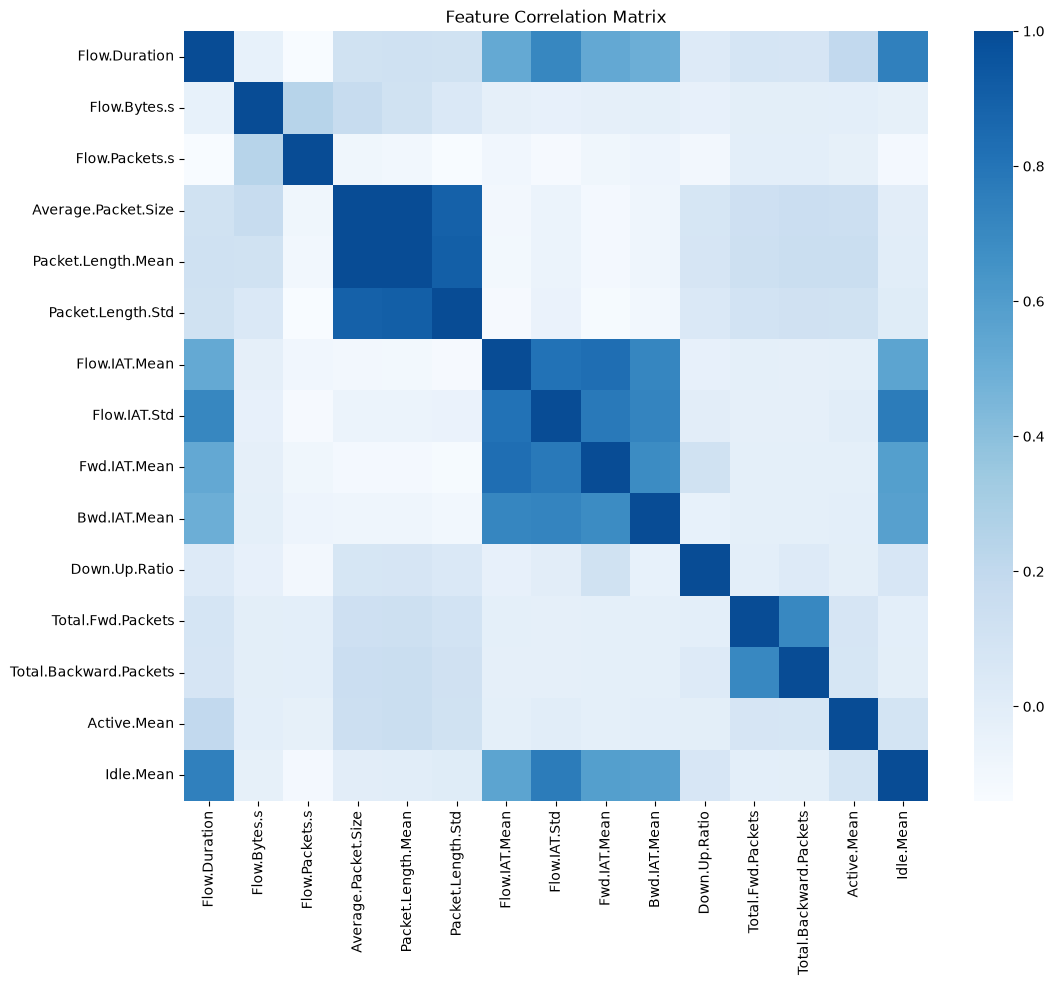

In [51]:
features = [
    'Flow.Duration',
    'Flow.Bytes.s',
    'Flow.Packets.s',
    'Average.Packet.Size',
    'Packet.Length.Mean',
    'Packet.Length.Std',
    'Flow.IAT.Mean',
    'Flow.IAT.Std',
    'Fwd.IAT.Mean',
    'Bwd.IAT.Mean',
    'Down.Up.Ratio',
    'Total.Fwd.Packets',
    'Total.Backward.Packets',
    'Active.Mean',
    'Idle.Mean'
]

corr = sample[features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr,cmap='Blues',center=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Key Findings

The exploratory analysis reveals several important characteristics:

1. Protocol distribution is highly imbalanced, with a small number of protocols dominating traffic volume.

2. Flow duration exhibits strong heavy-tailed behavior, indicating the coexistence of short-lived transactions and persistent sessions.

3. Throughput metrics contain substantial skewness and outliers.

4. Many traffic features are strongly correlated, suggesting significant redundancy in the original feature space.

5. The dataset appears to contain multiple distinct traffic behaviors that are not immediately explained by protocol labels alone.

These findings motivate the next stage of analysis:

- Feature Engineering
- Logarithmic Transformation
- Standardization
- Principal Component Analysis (PCA)
- Behavioral Clustering